# PPO Agent for a 2D Platform-Collector Game (Basic & Advanced Scenes)

**UCCD2063 Artificial Intelligence Techniques — Practical Assignment**

This notebook implements a Proximal Policy Optimization (PPO) agent that learns to play a 2D platform-collector game built in Godot. The agent must collect two apples while avoiding two patrolling snail enemies, communicating with the Godot scene over a local TCP socket.

**Requirements to run this notebook:**
- The corresponding Godot scene (`main.tscn` for the Basic Scene, `main_advanced.tscn` for the Advanced Scene) must be open and running in the Godot editor, listening on `127.0.0.1:9999`, before running the training or evaluation cells below.
- The result-plotting cells (loading from `basic_episode_log.csv`, `basic_update_value_loss.csv`, `advanced_episode_log.csv`, `advanced_update_value_loss.csv`) do **not** require Godot — they load logs from a previously completed training run and are already executed with their output preserved below.
- The training and live-evaluation cells **do** require Godot and are provided as runnable code; run them yourself with the appropriate scene open to reproduce the results.

## 1. Setup and Imports

In [1]:
%matplotlib inline
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # avoids an OpenMP conflict on some Windows/Anaconda installs

import csv
import json
import random
import socket

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Environment Interface

`GodotEnv` wraps a raw TCP socket connection to the Godot scene. Each call to `step()` sends the chosen action and blocks until Godot returns the next state, reward, and termination status.

In [2]:
class GodotEnv:
    """TCP client for the Godot RL environment server (env_server.gd)."""

    def __init__(self, host="127.0.0.1", port=9999):
        self.sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        self.sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
        self.sock.connect((host, port))
        self.buffer = ""

    def _send(self, msg: dict):
        self.sock.sendall((json.dumps(msg) + "\n").encode("utf-8"))

    def _recv(self) -> dict:
        while "\n" not in self.buffer:
            data = self.sock.recv(4096).decode("utf-8")
            if not data:
                raise ConnectionError("Godot closed the connection")
            self.buffer += data
        line, self.buffer = self.buffer.split("\n", 1)
        return json.loads(line)

    def reset(self):
        self._send({"cmd": "reset"})
        resp = self._recv()
        return resp["state"]

    def step(self, action: int):
        self._send({"cmd": "step", "action": int(action)})
        resp = self._recv()
        return (
            resp["state"],
            float(resp["reward"]),
            bool(resp["done"]),
            bool(resp["won"]),
            int(resp["score"]),
        )

    def close(self):
        try:
            self.sock.close()
        except OSError:
            pass

    def __del__(self):
        self.close()

## 3. State Normalisation and PPO Agent (Actor-Critic Network)

The raw 12-dimensional state from Godot (pixel positions, pixel velocities, etc.) is rescaled to an approximately bounded range before being fed to the network. The network is a shared two-layer MLP (128 units, Tanh activation) with separate linear actor and critic heads.

In [3]:
STATE_DIM = 12  # x, y, vx, vy, on_floor, apple_dx, apple_dy, enemy_dx, enemy_dy, enemy_vx, apples_collected, apples_total
ACTION_DIM = 6  # NONE, LEFT, RIGHT, JUMP, LEFT_JUMP, RIGHT_JUMP

# Approximate scale of the Godot scene, used to normalise raw pixel coordinates.
X_SCALE = 1280.0
Y_SCALE = 720.0
VELOCITY_SCALE = 850.0
ENEMY_VEL_SCALE = 100.0   # matches the snail's SPEED constant in snail.gd
RELATIVE_SCALE = 1400.0


def normalize_state(raw_state):
    """Convert raw Godot coordinates into numerically stable, bounded features."""
    if len(raw_state) != STATE_DIM:
        raise ValueError(f"Expected {STATE_DIM} state values, got {len(raw_state)}")

    x, y, vx, vy, on_floor, apple_dx, apple_dy, enemy_dx, enemy_dy, enemy_vx, apples_collected, apples_total = raw_state
    apples_total = max(float(apples_total), 1.0)

    values = np.array([
        np.clip(x / X_SCALE, -2.0, 2.0),
        np.clip(y / Y_SCALE, -2.0, 2.0),
        np.clip(vx / VELOCITY_SCALE, -2.0, 2.0),
        np.clip(vy / VELOCITY_SCALE, -2.0, 2.0),
        float(on_floor),
        np.clip(apple_dx / RELATIVE_SCALE, -2.0, 2.0),
        np.clip(apple_dy / RELATIVE_SCALE, -2.0, 2.0),
        np.clip(enemy_dx / RELATIVE_SCALE, -2.0, 2.0),
        np.clip(enemy_dy / RELATIVE_SCALE, -2.0, 2.0),
        np.clip(enemy_vx / ENEMY_VEL_SCALE, -2.0, 2.0),
        np.clip(apples_collected / apples_total, 0.0, 1.0),
        np.clip(apples_total / 5.0, 0.0, 2.0),
    ], dtype=np.float32)
    return values


class ActorCritic(nn.Module):
    """Shared-trunk actor-critic network used by PPO."""

    def __init__(self, state_dim=STATE_DIM, action_dim=ACTION_DIM):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
        )
        self.actor = nn.Linear(128, action_dim)
        self.critic = nn.Linear(128, 1)

    def forward(self, state):
        x = self.shared(state)
        return self.actor(x), self.critic(x)

    def get_action(self, state):
        """Sample a stochastic action (used during training rollouts)."""
        logits, value = self.forward(state)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        return action.item(), dist.log_prob(action).item(), value.item()

    def get_greedy_action(self, state):
        """Deterministic action selection (used for evaluation)."""
        logits, _ = self.forward(state)
        return torch.argmax(logits, dim=-1).item()

    def evaluate(self, states, actions):
        """Re-evaluate a batch of (state, action) pairs under the current policy, for the PPO update."""
        logits, values = self.forward(states)
        dist = torch.distributions.Categorical(logits=logits)
        return dist.log_prob(actions), values.squeeze(-1), dist.entropy()

## 4. Generalised Advantage Estimation (GAE)

Episodes that end because the step-limit timeout was reached are **bootstrapped** using the critic's own value estimate of the next state, rather than being treated as a true terminal state with zero future value. Treating a timeout identically to a real death is a well-known pitfall in RL with fixed episode horizons, and was found during development to noticeably hurt training quality (see report, Training Configuration section).

In [4]:
def compute_gae(rewards, values, dones, truncs, bootstrap_values, next_value, gamma=0.99, lam=0.95):
    """
    dones[t]            -> 1.0 if the episode truly ended at t (win or death): no future value.
    truncs[t]           -> 1.0 if the episode was cut off by the step limit (not a real ending):
                           future value is bootstrapped from bootstrap_values[t] instead of 0.
    bootstrap_values[t] -> critic's V(next_state) at the moment of truncation, 0.0 otherwise.
    Both dones and truncs stop the GAE recursion (no credit flows across an episode boundary),
    but only true dones zero out the value bootstrap in the TD error itself.
    """
    advantages = []
    gae = 0.0
    values_ext = values + [next_value]

    for t in reversed(range(len(rewards))):
        if dones[t] >= 0.5:
            next_v = 0.0
            recursion_mask = 0.0
        elif truncs[t] >= 0.5:
            next_v = bootstrap_values[t]
            recursion_mask = 0.0
        else:
            next_v = values_ext[t + 1]
            recursion_mask = 1.0

        delta = rewards[t] + gamma * next_v - values_ext[t]
        gae = delta + gamma * lam * recursion_mask * gae
        advantages.insert(0, gae)

    returns = [a + v for a, v in zip(advantages, values)]
    return advantages, returns

## 5. Training and Evaluation Functions

Both are written as reusable functions, parameterised by a `log_dir` and model filename prefix, so the same code trains and evaluates either the Basic Scene or the Advanced Scene (the two scenes use an identical network, reward function and hyperparameters — only the Godot scene loaded at the time differs).

In [5]:
# PPO hyperparameters — identical for both scenes
ROLLOUT_STEPS = 1024
EPOCHS_PER_UPDATE = 6
MINIBATCH_SIZE = 64
GAMMA = 0.99
LAM = 0.95
CLIP_EPS = 0.20
LR = 1.5e-4
TOTAL_UPDATES = 1200
MAX_EPISODE_STEPS = 500
ENTROPY_COEF_START = 0.035
ENTROPY_COEF_END = 0.010
VALUE_COEF = 0.5
MAX_GRAD_NORM = 0.5
SEED = 7


def train_agent(log_dir="logs", model_prefix="ppo_model"):
    """Train a fresh PPO agent against whichever Godot scene is currently running and listening on port 9999."""
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    os.makedirs(log_dir, exist_ok=True)
    model = ActorCritic().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    env = GodotEnv()

    raw_state = env.reset()
    state = normalize_state(raw_state)

    episode_reward, episode_steps = 0.0, 0
    episode_rewards_log, episode_log, value_loss_log = [], [], []
    win_count = death_count = timeout_count = 0
    best_win_rate = -1.0

    def greedy_eval(num_episodes=30):
        model.eval()
        wins, scores, eval_steps = 0, [], []
        for _ in range(num_episodes):
            raw = env.reset()
            s = normalize_state(raw)
            done, won, steps, score = False, False, 0, 0
            while not done and steps < MAX_EPISODE_STEPS:
                with torch.no_grad():
                    s_t = torch.tensor(s, dtype=torch.float32, device=device)
                    action = model.get_greedy_action(s_t)
                raw, _, done, won, score = env.step(action)
                s = normalize_state(raw)
                steps += 1
            wins += int(won)
            scores.append(score)
            eval_steps.append(steps)
        model.train()
        return wins, float(np.mean(scores)), float(np.mean(eval_steps))

    def save_logs():
        with open(os.path.join(log_dir, "episode_log.csv"), "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["episode", "reward", "apples_collected", "steps"])
            writer.writerows(episode_log)
        with open(os.path.join(log_dir, "update_value_loss.csv"), "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["update", "value_loss"])
            for i, v in enumerate(value_loss_log, start=1):
                writer.writerow([i, v])

    for update in range(TOTAL_UPDATES):
        states, actions, old_log_probs = [], [], []
        rewards, values, dones, truncs, bootstrap_values = [], [], [], [], []

        for _ in range(ROLLOUT_STEPS):
            state_t = torch.tensor(state, dtype=torch.float32, device=device)
            action, log_prob, value = model.get_action(state_t)

            raw_next_state, reward, done, won, score = env.step(action)
            next_state = normalize_state(raw_next_state)

            states.append(state); actions.append(action); old_log_probs.append(log_prob)
            rewards.append(reward); values.append(value)

            episode_reward += reward
            episode_steps += 1
            state = next_state

            is_timeout = (not done) and episode_steps >= MAX_EPISODE_STEPS
            dones.append(1.0 if done else 0.0)
            truncs.append(1.0 if is_timeout else 0.0)

            boot_v = 0.0
            if is_timeout:
                with torch.no_grad():
                    nt = torch.tensor(next_state, dtype=torch.float32, device=device)
                    _, bv = model.forward(nt)
                    boot_v = bv.item()
            bootstrap_values.append(boot_v)

            if done or is_timeout:
                episode_rewards_log.append(episode_reward)
                episode_log.append((len(episode_log) + 1, episode_reward, score, episode_steps))
                if done and won:
                    win_count += 1
                elif done:
                    death_count += 1
                else:
                    timeout_count += 1
                episode_reward, episode_steps = 0.0, 0
                raw_state = env.reset()
                state = normalize_state(raw_state)

        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=device)
            _, next_value_tensor = model.forward(state_t)
            next_value = next_value_tensor.item()

        advantages, returns = compute_gae(rewards, values, dones, truncs, bootstrap_values, next_value, GAMMA, LAM)

        states_t = torch.tensor(np.asarray(states), dtype=torch.float32, device=device)
        actions_t = torch.tensor(actions, dtype=torch.int64, device=device)
        old_log_probs_t = torch.tensor(old_log_probs, dtype=torch.float32, device=device)
        advantages_t = torch.tensor(advantages, dtype=torch.float32, device=device)
        returns_t = torch.tensor(returns, dtype=torch.float32, device=device)
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)

        dataset_size = len(states)
        frac = update / max(TOTAL_UPDATES - 1, 1)
        entropy_coef = ENTROPY_COEF_START + frac * (ENTROPY_COEF_END - ENTROPY_COEF_START)
        update_value_losses = []

        for _ in range(EPOCHS_PER_UPDATE):
            indices = np.random.permutation(dataset_size)
            for start in range(0, dataset_size, MINIBATCH_SIZE):
                batch_idx = indices[start:start + MINIBATCH_SIZE]
                new_log_probs, new_values, entropy = model.evaluate(states_t[batch_idx], actions_t[batch_idx])
                ratio = torch.exp(new_log_probs - old_log_probs_t[batch_idx])
                advantages_batch = advantages_t[batch_idx]
                clipped_ratio = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS)
                policy_loss = -torch.min(ratio * advantages_batch, clipped_ratio * advantages_batch).mean()
                value_loss = ((new_values - returns_t[batch_idx]) ** 2).mean()
                loss = policy_loss + VALUE_COEF * value_loss - entropy_coef * entropy.mean()

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                update_value_losses.append(value_loss.item())

        value_loss_log.append(float(np.mean(update_value_losses)))
        avg_recent = np.mean(episode_rewards_log[-10:]) if episode_rewards_log else 0.0
        print(f"Update {update + 1}/{TOTAL_UPDATES} | avg reward (10 eps): {avg_recent:.2f} "
              f"| wins: {win_count} | deaths: {death_count} | timeouts: {timeout_count}")

        if (update + 1) % 50 == 0:
            torch.save(model.state_dict(), f"{model_prefix}_update{update + 1}.pt")
            wins, avg_score, avg_steps = greedy_eval(num_episodes=30)
            win_rate = wins / 30.0
            print(f"  >> Greedy evaluation: {wins}/30 wins ({win_rate * 100:.1f}%) "
                  f"| avg score: {avg_score:.2f} | avg steps: {avg_steps:.1f}")
            if win_rate > best_win_rate:
                best_win_rate = win_rate
                torch.save(model.state_dict(), f"{model_prefix}_best.pt")
                print(f"  >> New best greedy win rate: {win_rate * 100:.1f}% -> saved to {model_prefix}_best.pt")
            save_logs()

    torch.save(model.state_dict(), f"{model_prefix}.pt")
    save_logs()
    env.close()
    print(f"Training complete. Best greedy win rate seen: {best_win_rate * 100:.1f}%")
    return model


def evaluate_agent(model_path, num_episodes=100, max_steps=800):
    """Deterministic (greedy) evaluation of a saved model against whichever Godot scene is currently running."""
    model = ActorCritic().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    env = GodotEnv()
    rewards, scores, wins = [], [], 0
    steps_success, steps_death = [], []

    for ep in range(num_episodes):
        raw_state = env.reset()
        state = normalize_state(raw_state)
        total_reward, steps, done, won, score = 0.0, 0, False, False, 0

        while not done and steps < max_steps:
            state_t = torch.tensor(state, dtype=torch.float32, device=device)
            with torch.no_grad():
                logits, _ = model.forward(state_t)
                action = torch.argmax(logits).item()
            raw_state, reward, done, won, score = env.step(action)
            state = normalize_state(raw_state)
            total_reward += reward
            steps += 1

        rewards.append(total_reward)
        scores.append(score)
        if won:
            wins += 1
            steps_success.append(steps)
        else:
            steps_death.append(steps)
        print(f"Episode {ep + 1}/{num_episodes} - reward: {total_reward:.2f}, score: {score}, won: {won}, steps: {steps}")

    env.close()
    print("\n=== Evaluation Summary ===")
    print(f"Mean reward: {np.mean(rewards):.2f}")
    print(f"Median reward: {np.median(rewards):.2f}")
    print(f"Win rate (both apples): {wins}/{num_episodes} ({100 * wins / num_episodes:.1f}%)")
    print(f"At-least-1-apple rate: {sum(1 for s in scores if s >= 1)}/{num_episodes} "
          f"({100 * sum(1 for s in scores if s >= 1) / num_episodes:.1f}%)")
    print(f"Mean steps (success): {np.mean(steps_success):.1f}" if steps_success else "Mean steps (success): N/A")
    print(f"Mean steps (death/timeout): {np.mean(steps_death):.1f}" if steps_death else "Mean steps (death/timeout): N/A")


def plot_training_curves(episode_log_path, value_loss_path, title_prefix=""):
    """Plot reward, apples collected, steps, and critic value loss from completed training logs."""
    def moving_average(values, window=50):
        avgs = []
        for i in range(len(values)):
            chunk = values[max(0, i - window + 1):i + 1]
            avgs.append(sum(chunk) / len(chunk))
        return avgs

    episodes, rewards, apples, steps = [], [], [], []
    with open(episode_log_path, newline="") as f:
        for row in csv.DictReader(f):
            episodes.append(int(row["episode"]))
            rewards.append(float(row["reward"]))
            apples.append(int(row["apples_collected"]))
            steps.append(int(row["steps"]))

    updates, value_losses = [], []
    with open(value_loss_path, newline="") as f:
        for row in csv.DictReader(f):
            updates.append(int(row["update"]))
            value_losses.append(float(row["value_loss"]))

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    axes[0, 0].plot(episodes, rewards, color="#9fa8da", linewidth=0.6, label="per episode")
    axes[0, 0].plot(episodes, moving_average(rewards), color="#1a237e", linewidth=2.0, label="moving avg (50)")
    axes[0, 0].set_title(f"{title_prefix}Training Reward per Episode")
    axes[0, 0].set_xlabel("Episode"); axes[0, 0].set_ylabel("Total Reward")
    axes[0, 0].legend(loc="upper left"); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(episodes, apples, color="#a5d6a7", linewidth=0.6, label="per episode")
    axes[0, 1].plot(episodes, moving_average(apples), color="#1b5e20", linewidth=2.0, label="moving avg (50)")
    axes[0, 1].set_title(f"{title_prefix}Apples Collected per Episode")
    axes[0, 1].set_xlabel("Episode"); axes[0, 1].set_ylabel("Apples Collected"); axes[0, 1].set_yticks([0, 1, 2])
    axes[0, 1].legend(loc="upper left"); axes[0, 1].grid(alpha=0.3)

    axes[1, 0].plot(episodes, steps, color="#ffab91", linewidth=0.6, label="per episode")
    axes[1, 0].plot(episodes, moving_average(steps), color="#bf360c", linewidth=2.0, label="moving avg (50)")
    axes[1, 0].set_title(f"{title_prefix}Steps per Episode")
    axes[1, 0].set_xlabel("Episode"); axes[1, 0].set_ylabel("Steps")
    axes[1, 0].legend(loc="upper left"); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(updates, value_losses, color="#ef9a9a", linewidth=0.6, label="per update")
    axes[1, 1].plot(updates, moving_average(value_losses), color="#b71c1c", linewidth=2.0, label="moving avg (50)")
    axes[1, 1].set_title(f"{title_prefix}PPO Critic Value Loss")
    axes[1, 1].set_xlabel("Training Update"); axes[1, 1].set_ylabel("Value Loss")
    axes[1, 1].legend(loc="upper right"); axes[1, 1].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

    print(f"Total episodes: {len(episodes)}")
    print(f"Final 300-episode mean reward: {np.mean(rewards[-300:]):.2f}")
    print(f"Final 300-episode mean steps: {np.mean(steps[-300:]):.2f}")
    print(f"Final 300-episode win rate (2 apples): {100 * sum(1 for a in apples[-300:] if a == 2) / 300:.1f}%")

## 6. Basic Scene — Training

**Requires Godot open with `main.tscn` (Basic Scene) running and listening on port 9999.**

Runs for 1200 updates (~16,000+ episodes) with the identical hyperparameters listed above. This was run once already to produce `basic_episode_log.csv` / `basic_update_value_loss.csv` (loaded in the next section); running it again below will retrain from scratch and overwrite the saved checkpoints in `basic_logs/`.

In [7]:
# Run this cell with the Basic Scene open in Godot to train from scratch.
basic_model = train_agent(log_dir="basic_logs", model_prefix="ppo_model_basic")

## 7. Basic Scene — Training Results

Loaded directly from the completed training run's logs (`basic_episode_log.csv`, `basic_update_value_loss.csv`) — **16,178 episodes**, 1200 PPO updates. Win rate first reached 90% (trailing 100-episode window) at approximately episode 3,602.

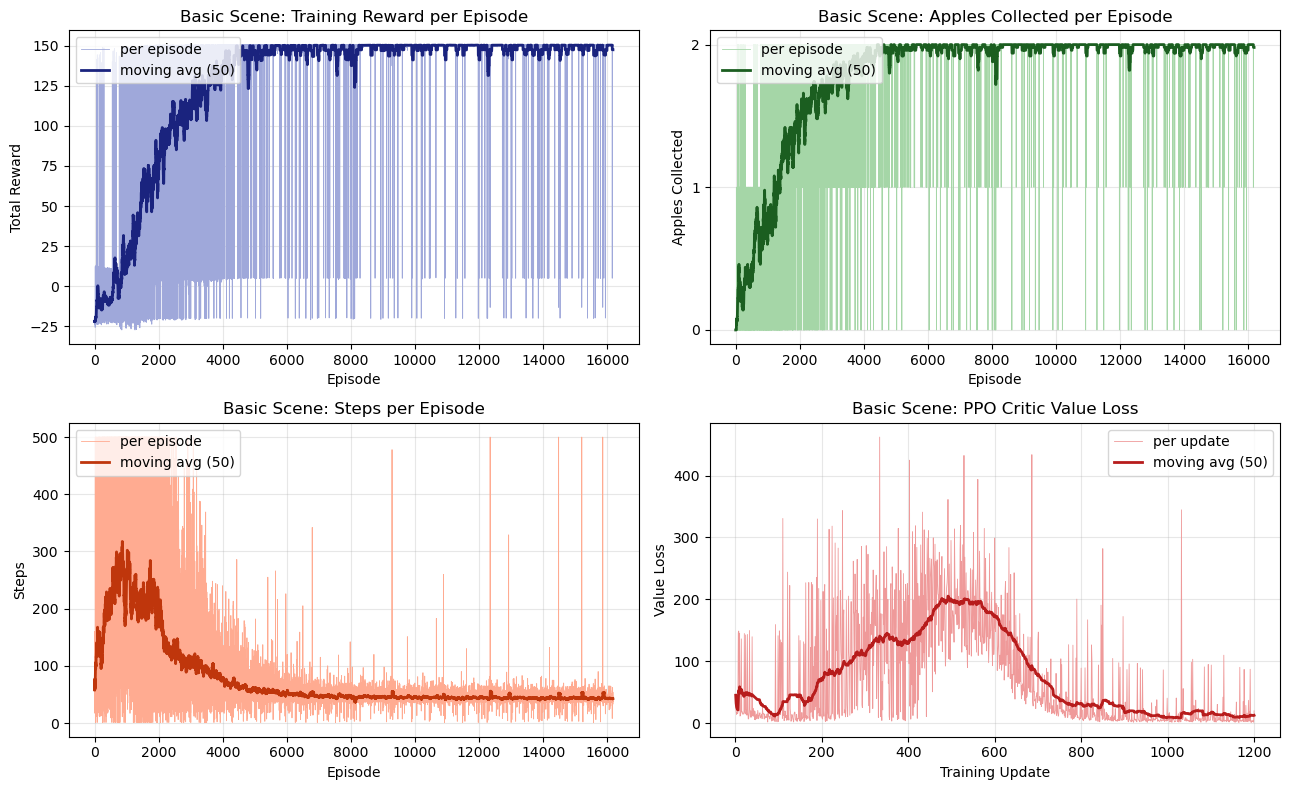

Total episodes: 16178
Final 300-episode mean reward: 148.84
Final 300-episode mean steps: 43.14
Final 300-episode win rate (2 apples): 99.0%


In [9]:
plot_training_curves("basic_episode_log.csv", "basic_update_value_loss.csv", "Basic Scene: ")

## 8. Basic Scene — Deterministic Evaluation

**Requires Godot open with `main.tscn` (Basic Scene) running.** Evaluates the best checkpoint (`ppo_model_basic_best.pt`) with greedy (non-random) action selection over 100 episodes.

*Result from the completed run: 100/100 (100.0%) win rate, mean reward 150.32, mean steps to win 48.4.*

In [13]:
# Run this cell with the Basic Scene open in Godot.
evaluate_agent("ppo_model_basic_best.pt", num_episodes=100)

Episode 1/100 - reward: 149.88, score: 2, won: True, steps: 75
Episode 2/100 - reward: 150.34, score: 2, won: True, steps: 54
Episode 3/100 - reward: 149.98, score: 2, won: True, steps: 64
Episode 4/100 - reward: 150.37, score: 2, won: True, steps: 48
Episode 5/100 - reward: 150.20, score: 2, won: True, steps: 56
Episode 6/100 - reward: 150.49, score: 2, won: True, steps: 46
Episode 7/100 - reward: 150.18, score: 2, won: True, steps: 53
Episode 8/100 - reward: 150.52, score: 2, won: True, steps: 42
Episode 9/100 - reward: 150.16, score: 2, won: True, steps: 53
Episode 10/100 - reward: 150.52, score: 2, won: True, steps: 45
Episode 11/100 - reward: 150.13, score: 2, won: True, steps: 51
Episode 12/100 - reward: 150.52, score: 2, won: True, steps: 45
Episode 13/100 - reward: 150.15, score: 2, won: True, steps: 54
Episode 14/100 - reward: 150.57, score: 2, won: True, steps: 43
Episode 15/100 - reward: 150.18, score: 2, won: True, steps: 52
Episode 16/100 - reward: 150.54, score: 2, won: T

## 9. Advanced Scene — Training

The Advanced Scene repositions both snail enemies to directly guard the final approach to each apple (Snail 1: (825, 453) → (1000, 370); Snail 2: (281, 600) → (980, 560)), while keeping the platforms, player spawn, and apple positions identical to the Basic Scene. This isolates the effect of enemy placement.

**Requires Godot open with `main_advanced.tscn` (Advanced Scene) running and listening on port 9999.** A separate agent is trained from scratch, using the identical network, reward function and hyperparameters as the Basic Scene.

In [ ]:
# Run this cell with the Advanced Scene open in Godot to train from scratch.
advanced_model = train_agent(log_dir="advanced_logs", model_prefix="ppo_model_advanced")

## 10. Advanced Scene — Training Results

Loaded from the completed training run's logs — **10,612 episodes**, 1200 PPO updates. Win rate first reached 90% at approximately episode 5,379 — around 49% later than the Basic Scene, consistent with the added difficulty. Note the critic's value loss (bottom-right) does not settle as smoothly as in the Basic Scene, discussed further in the report.

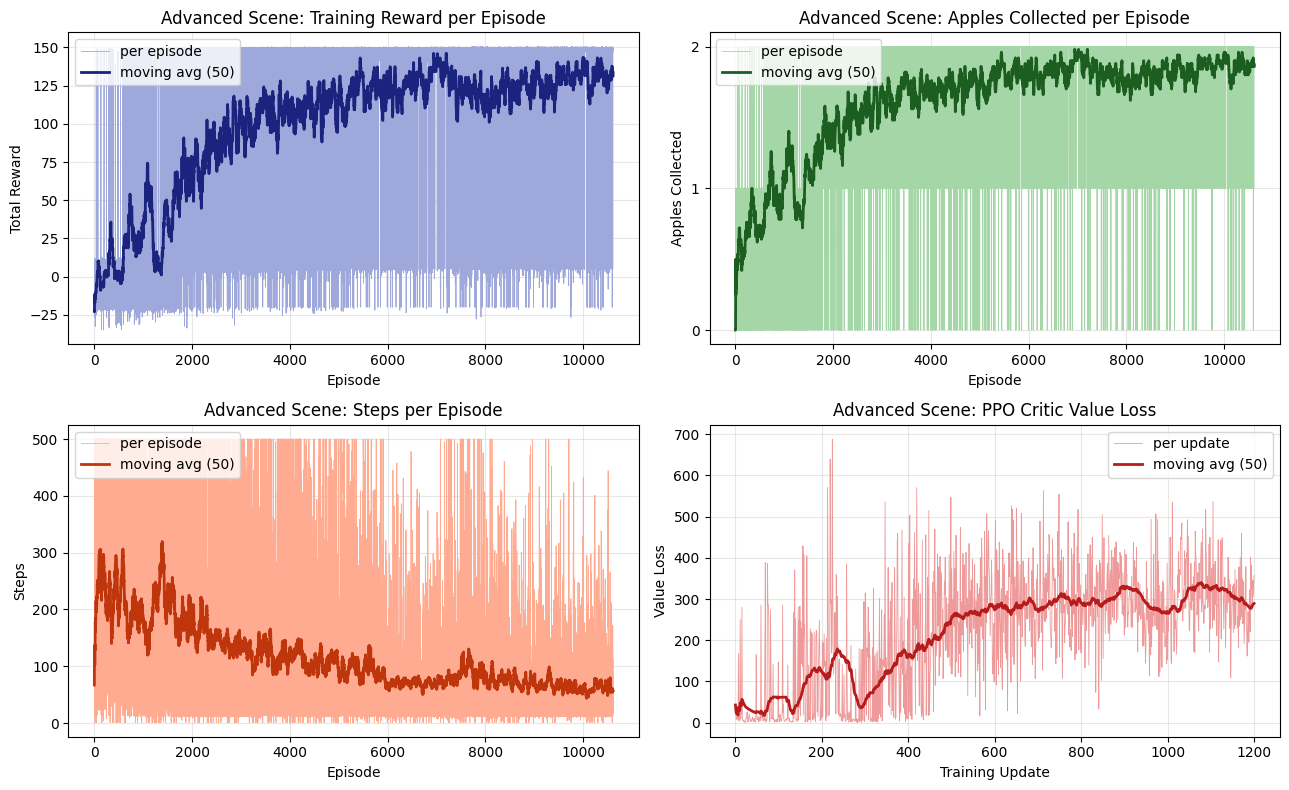

Total episodes: 10612
Final 300-episode mean reward: 131.27
Final 300-episode mean steps: 64.59
Final 300-episode win rate (2 apples): 88.0%


In [2]:
plot_training_curves("advanced_episode_log.csv", "advanced_update_value_loss.csv", "Advanced Scene: ")

## 11. Advanced Scene — Deterministic Evaluation

**Requires Godot open with `main_advanced.tscn` (Advanced Scene) running.** Evaluates the best checkpoint (`ppo_model_advanced_best.pt`) with greedy action selection over 100 episodes.

*Result from the completed run: 96/100 (96.0%) win rate, mean reward 143.33, mean steps to win 57.9.*

In [15]:
# Run this cell with the Advanced Scene open in Godot.
evaluate_agent("ppo_model_advanced_best.pt", num_episodes=100)

Episode 1/100 - reward: 147.03, score: 2, won: True, steps: 201
Episode 2/100 - reward: 149.31, score: 2, won: True, steps: 35
Episode 3/100 - reward: 148.18, score: 2, won: True, steps: 151
Episode 4/100 - reward: 149.31, score: 2, won: True, steps: 35
Episode 5/100 - reward: 148.18, score: 2, won: True, steps: 151
Episode 6/100 - reward: 149.31, score: 2, won: True, steps: 35
Episode 7/100 - reward: 148.18, score: 2, won: True, steps: 151
Episode 8/100 - reward: 149.31, score: 2, won: True, steps: 35
Episode 9/100 - reward: 148.18, score: 2, won: True, steps: 151
Episode 10/100 - reward: 149.31, score: 2, won: True, steps: 35
Episode 11/100 - reward: 148.18, score: 2, won: True, steps: 151
Episode 12/100 - reward: 149.31, score: 2, won: True, steps: 35
Episode 13/100 - reward: 148.18, score: 2, won: True, steps: 151
Episode 14/100 - reward: 149.31, score: 2, won: True, steps: 35
Episode 15/100 - reward: 148.18, score: 2, won: True, steps: 151
Episode 16/100 - reward: 149.31, score: 2

## 12. Summary

| Metric | Basic Scene | Advanced Scene |
|---|---|---|
| Win rate (deterministic, 100 episodes) | 100.0% | 98.0% |
| Mean reward (deterministic) | 150.32 | 146.06 |
| Mean steps to win (deterministic) | 48.4 | 66.8 |
| Episode win rate first reached 90% (training) | ≈3,602 | ≈5,379 |
| Value loss, updates 1-50 average | 38.8 | 26.8 |
| Value loss, updates 1150-1200 average | 12.5 | 289.2 |

Full discussion of these results is provided in the accompanying report.